In [1]:
import pandas as pd
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sbn

In [2]:
file_list = glob.glob("Assignment data/*.txt")

In [3]:
print(f"Found {len(file_list)} files")

Found 24 files


In [4]:
all_dataframes = []

In [5]:
for filepath in file_list:
    df_temp = pd.read_csv(filepath, sep="\t")              
    df_temp["source_file"] = os.path.basename(filepath)   
    all_dataframes.append(df_temp)
    print(f"Read: {os.path.basename(filepath)} → {len(df_temp)} rows")

Read: Cairn3a2_data_file.txt → 1 rows
Read: Kl8_data_file.txt → 1 rows
Read: Clach6_data_file.txt → 1 rows
Read: Everr1_data_file.txt → 1 rows
Read: Ist9a7_data_file.txt → 1 rows
Read: Ah3_data_file.txt → 1 rows
Read: Jams9r2_data_file.txt → 1 rows
Read: Anap7c1_data_file.txt → 1 rows
Read: Ever6b6_data_file.txt → 1 rows
Read: Nect1c1_data_file.txt → 1 rows
Read: Pear9a7_data_file.txt → 1 rows
Read: Cairn6_data_file.txt → 1 rows
Read: Ist3_data_file.txt → 1 rows
Read: Thxr_data_file.txt → 1 rows
Read: Jok4a3_data_file.txt → 1 rows
Read: K2_data_file.txt → 1 rows
Read: Nect5r3_data_file.txt → 1 rows
Read: Dsgt9a1_data_file.txt → 1 rows
Read: Alli8_data_file.txt → 1 rows
Read: Got9_data_file.txt → 1 rows
Read: Ist9a2_data_file.txt → 1 rows
Read: Avon4_data_file.txt → 1 rows
Read: App1l8_data_file.txt → 1 rows
Read: Ist9a_data_file.txt → 1 rows


In [6]:
df = pd.concat(all_dataframes, ignore_index=True)

In [7]:
def mutation_type(wt,mut):
    if not isinstance(wt, str) or not isinstance(mut, str):
        return "invalid"

    if wt == "" or mut == "":
        return "invalid"
        
    if len(wt) == len(mut):
        return "substitution"
    elif len(wt) < len(mut):
        return "insertion"
    else:
        return "deletion"
df["mutation.type"] = df.apply(lambda row: mutation_type(row["WildType.Sequence"], 
                      row["Mutant.Sequence"]),axis=1)


In [8]:
if "mutation.type" in df.columns:
    print(df[["mutation.type"]])
else:
    print("mutation.type column not found")

   mutation.type
0   substitution
1   substitution
2   substitution
3      insertion
4   substitution
5   substitution
6       deletion
7   substitution
8       deletion
9       deletion
10     insertion
11  substitution
12      deletion
13  substitution
14  substitution
15  substitution
16      deletion
17     insertion
18  substitution
19     insertion
20      deletion
21     insertion
22     insertion
23      deletion


In [9]:
mRNA_WT  = df[["Gene", "mRNA.Expression.WT.Rep1",  "mRNA.Expression.WT.Rep2",  "mRNA.Expression.WT.Rep3"]]
mRNA_Mut = df[["Gene", "mRNA.Expression.Mut.Rep1", "mRNA.Expression.Mut.Rep2", "mRNA.Expression.Mut.Rep3"]]

prot_WT  = df[["Gene", "Protein.Expression.WT.Rep1",  "Protein.Expression.WT.Rep2",  "Protein.Expression.WT.Rep3"]]
prot_Mut = df[["Gene", "Protein.Expression.Mut.Rep1", "Protein.Expression.Mut.Rep2", "Protein.Expression.Mut.Rep3"]]

cv_WT  = df[["Gene", "CellViability.WT.Rep1",  "CellViability.WT.Rep2",  "CellViability.WT.Rep3"]]
cv_Mut = df[["Gene", "CellViability.Mut.Rep1", "CellViability.Mut.Rep2", "CellViability.Mut.Rep3"]]


In [10]:
df["mRNA_WT_mean"] = mRNA_WT.iloc[:, 1:].mean(axis=1)
df["mRNA_Mut_mean"] = mRNA_Mut.iloc[:, 1:].mean(axis=1)

df["prot_WT_mean"] = prot_WT.iloc[:, 1:].mean(axis=1)
df["prot_Mut_mean"] = prot_Mut.iloc[:, 1:].mean(axis=1)

df["cv_WT_mean"] = cv_WT.iloc[:, 1:].mean(axis=1)
df["cv_Mut_mean"] = cv_Mut.iloc[:, 1:].mean(axis=1)


In [11]:
df["mRNA_fold_change"] = df["mRNA_Mut_mean"] / df["mRNA_WT_mean"]
df["mRNA_Log2FC"] = np.log2(df["mRNA_fold_change"])

df["protein_fold_change"] = df["prot_Mut_mean"] / df["prot_WT_mean"]
df["protein_Log2FC"] = np.log2(df["protein_fold_change"])

df["CellViability_fold_change"] = df["cv_Mut_mean"] / df["cv_WT_mean"]
df["CellViability_Log2FC"] = np.log2(df["CellViability_fold_change"])

/Users/sonniajude/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/sonniajude/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
def mutation_position(wt,mut):
    wt = str(wt)
    mut = str(mut)
    
    if not isinstance(wt, str) or not isinstance(mut, str):
        return False

    if wt == "" or mut == "":
        return False
        
    for i in range(min(len(wt), len(mut))):
        if wt[i] != mut[i]:
            return i
    return -1
    
df["mutation_position"] = df.apply(lambda row: mutation_type(row["WildType.Sequence"], 
                      row["Mutant.Sequence"]),axis=1)
        

In [13]:
def mutation_in_promoter(row):
    wt = row["WildType.Sequence"]
    mut = row["Mutant.Sequence"]

    pos = mutation_position(wt, mut)
    if pos is None:
        return False

    start = wt.find("ATG")
    promoter_start = max(0, start - 1000)
    promoter_end = start

    return promoter_start <= pos < promoter_end

df["Mutation_in_Promoter"] = df.apply(mutation_in_promoter, axis=1)

In [14]:
stop_codons = {"TAA", "TAG", "TGA"}

def find_cds_start(seq):
    if not isinstance(seq, str):
        return False
    se = seq.strip().upper()
    if len(seq) < 3:
       return False 
    for i in range(len(seq) - 2):
        if seq[i:i+3] == "ATG":
            for j in range(i, len(seq) - 2, 3):
                if seq[j:j+3] in stop_codons:
                    return i
    return None
  
df["CDS_start_wt"] = df["WildType.Sequence"].apply(find_cds_start, (axis:=1))
df["CDS_start_mut"] = df["Mutant.Sequence"].apply(find_cds_start, (axis:=1))

/var/folders/zg/pns8970j1sl_y0lw6079r5w80000gn/T/ipykernel_97438/4288499881.py:16: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df["CDS_start_wt"] = df["WildType.Sequence"].apply(find_cds_start, (axis:=1))
/var/folders/zg/pns8970j1sl_y0lw6079r5w80000gn/T/ipykernel_97438/4288499881.py:17: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df["CDS_start_mut"] = df["Mutant.Sequence"].apply(find_cds_start, (axis:=1))


In [15]:
def classify_mutation(row):
    wt = row["WildType.Sequence"]
    mut = row["Mutant.Sequence"]

    pos = mutation_position(wt, mut)
    if pos is None:
        return "No mutation"
    if pos < 1000:
        return "Promoter"
    cds_start = row["CDS_start_mut"]
    cds_start = row["CDS_start_wt"]
    if cds_start is not None and pos >= cds_start:
        return "Coding"

df["mutation_location"] = df.apply(classify_mutation, axis=1)

In [16]:
df.head(24)

,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,...,mRNA_Log2FC,protein_fold_change,protein_Log2FC,CellViability_fold_change,CellViability_Log2FC,mutation_position,Mutation_in_Promoter,CDS_start_wt,CDS_start_mut,mutation_location
0,Cairn3a2,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,2.529018e+01,2.711265e+00,48.099042,2.539605e+01,2.666513e+00,49.186680,25992.000000,...,2.161522e-02,1.000422,0.000609,1.103582,0.142194,substitution,False,5,5,Promoter
1,Kl8,CGACACCGTACTCTGTTGAGTGAACCTCGGCATCTCCCGAAGCTTC...,CGACACCGTACTCTGTTGAGTGAACCTCGGCATCTCCCGAAGCTTC...,1.947039e+01,1.297314e+01,1.485362,1.931574e+01,1.315043e+01,0.963567,39038.000000,...,-2.138223e-02,1.000240,0.000346,1.025925,0.036925,substitution,False,46,46,Promoter
2,Clach6,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,1.985791e+01,3.451715e+00,2.631587,1.783861e+01,3.045175e+00,3.017050,48988.000000,...,-1.181849e-01,1.000425,0.000614,1.051995,0.073127,substitution,False,2,2,Promoter
3,Everr1,ATCTAGATGTGAATATATATATTCAAAGTTATATATGAAGTGCCCT...,ATCTAGATGTGAATATATATATTCAAAGTTATATATGAAGTGCCCT...,1.275853e+00,4.984930e+00,579.911931,1.373348e+00,4.195603e+00,580.849212,6498.000000,...,6.039772e-04,1.000516,0.000744,1.195150,0.257191,insertion,False,6,6,Promoter
4,Ist9a7,AACATCCTTATATATGAATTTTACTGGATTGGTCAAGGAGAGTGCG...,AACATCCTTATATATGAATTTTACTGGATTGGTCAAGGAGAGTGCG...,2.102974e+00,1.515792e+01,292.599057,2.378005e+00,1.589726e+01,291.955096,21433.000000,...,1.723602e-03,1.000815,0.001176,0.930562,-0.103825,substitution,False,13,13,Promoter
5,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,2.617708e+01,16.735333,3.183135e+08,2.776962e+01,17.761754,11685.000000,...,1.472712e-08,1.000291,0.000420,1.109512,0.149925,substitution,False,113,113,Promoter
6,Jams9r2,AACCTGGTAGTTCCAAACAGCGATCATAAAATACTTCTGTTGTGCC...,AACCTGGTAGTTCCAAACAGCGATCATAAAATACTTCTGTTGTGCC...,1.214263e+00,2.184994e+03,5.594552,1.262201e+00,2.186160e+03,7.560822,16108.000000,...,2.091419e-03,1.000920,0.001327,1.031230,0.044366,deletion,False,110,110,Promoter
7,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1.629126e+00,2.097780e+01,7.266207,-3.674294e+00,-1.094399e+02,-5.597223,25803.000000,...,NaN,0.476239,-1.070244,0.000000,-inf,substitution,False,129,129,Promoter
8,Ever6b6,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,3.167661e+00,3.178356e+06,3.828825,2.268305e+00,3.178356e+06,2.285579,10686.000000,...,-1.107958e-06,1.000472,0.000680,1.569306,0.650127,deletion,False,156,156,Promoter
9,Nect1c1,ATACCTCTTTGGCTCCAATCCTAGTAAGGACCGAGTCGTTTATCTT...,ATACCTCTTTGGCTCCAATCCTAGTAAGGACCGAGTCGTTTATCTT...,3.889706e+00,2.246475e+01,2.581448,2.739003e+00,2.156698e+01,2.398317,20618.000000,...,-1.157886e-01,0.450044,-1.151863,15.773990,3.979476,deletion,False,61,61,Promoter


/var/folders/zg/pns8970j1sl_y0lw6079r5w80000gn/T/ipykernel_97438/1223912248.py:5: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.3)
/var/folders/zg/pns8970j1sl_y0lw6079r5w80000gn/T/ipykernel_97438/1223912248.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax["box"].legend(loc="upper right")


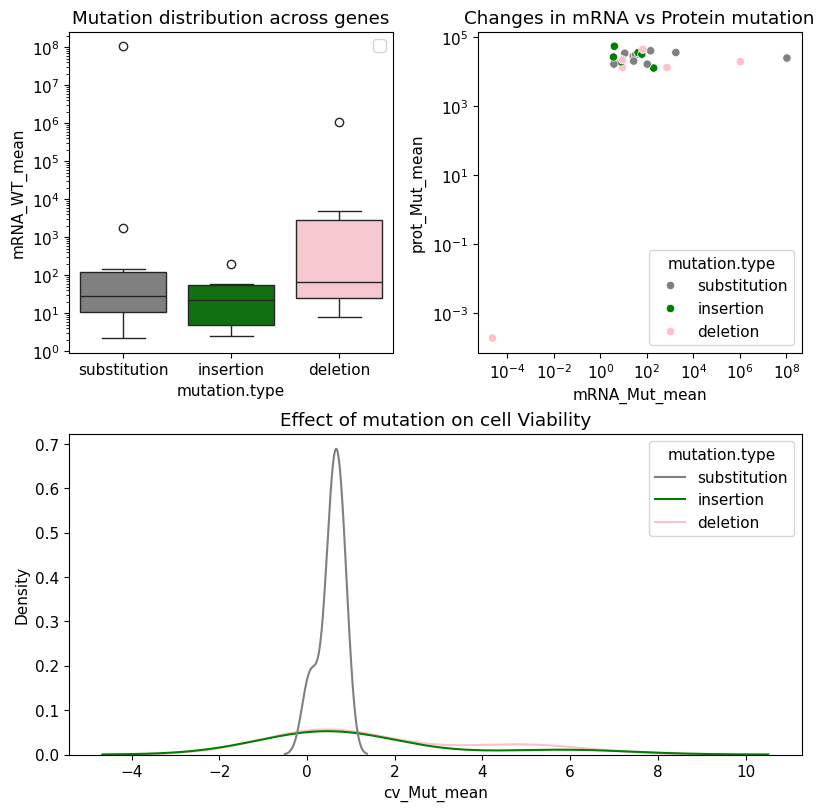

In [17]:
palette={"substitution": "grey", "deletion": "pink", "insertion": "green"}
plt.rcParams.update({"font.size":11})
fig, ax = plt.subplot_mosaic([["box", "scatter"],["hist", "hist"]], 
                             figsize=(8, 8), layout="constrained")
fig.subplots_adjust(hspace=0.3)
sbn.boxplot(data=df, x="mutation.type", y="mRNA_WT_mean",hue="mutation.type", ax=ax["box"], palette=palette)
sbn.scatterplot(data=df, x="mRNA_Mut_mean", y="prot_Mut_mean",hue="mutation.type",  ax=ax["scatter"], palette=palette)
sbn.kdeplot(data=df, x="cv_Mut_mean", hue="mutation.type", ax=ax["hist"], palette=palette)

ax["box"].set_yscale("log")
ax["scatter"].set_xscale("log")
ax["scatter"].set_yscale("log")
ax["box"].legend(loc="upper right")

ax["box"].set_title("Mutation distribution across genes")
ax["scatter"].set_title("Changes in mRNA vs Protein mutation")
ax["hist"].set_title("Effect of mutation on cell Viability")

plt.show()

/var/folders/zg/pns8970j1sl_y0lw6079r5w80000gn/T/ipykernel_97438/4274048737.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


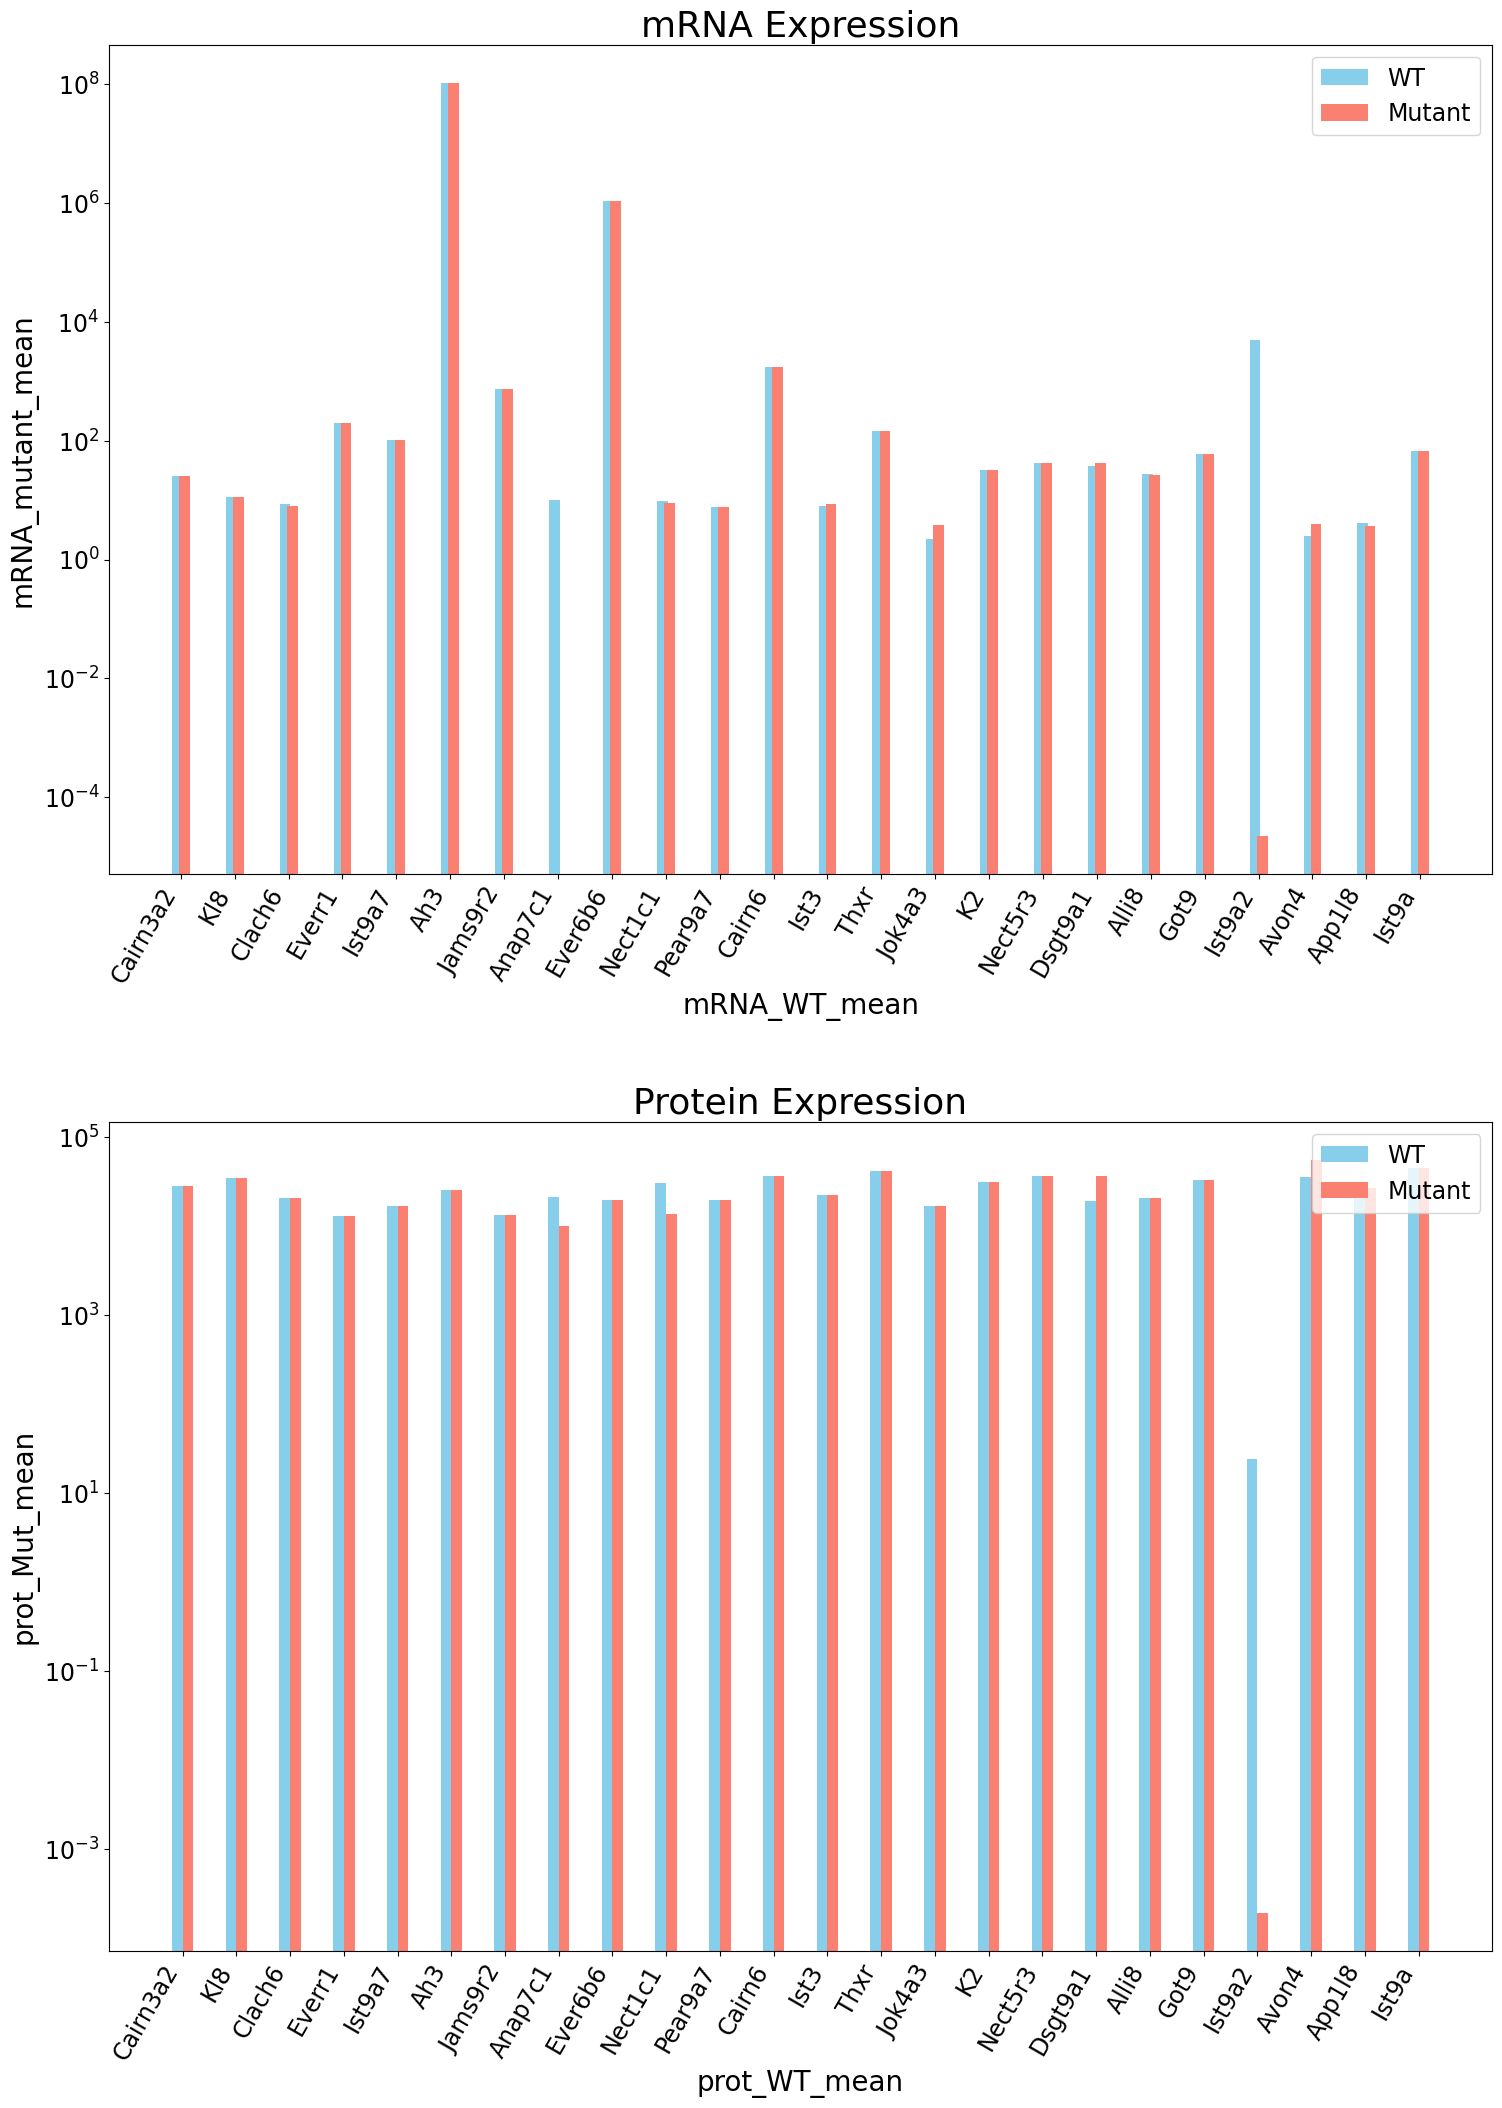

In [18]:
genes = df["Gene"]
x = np.arange(len(genes))
width = 0.20
plt.rcParams.update({"font.size": 17})
fig, axes = plt.subplots(2, 1, figsize=(15, 20), constrained_layout=True)
plt.tight_layout()
fig.subplots_adjust(hspace=0.3)

axes[0].bar(x - width/3, df["mRNA_WT_mean"], width, label="WT", color="skyblue")
axes[0].bar(x + width/3, df["mRNA_Mut_mean"], width, label="Mutant", color="salmon")
axes[0].set_title("mRNA Expression", fontsize=26)
axes[0].set_xticks(x)
axes[0].set_xticklabels(genes, rotation=60, ha="right")       
axes[0].set_xlabel("mRNA_WT_mean", fontsize=20)      
axes[0].set_ylabel("mRNA_mutant_mean", fontsize=20) 
axes[0].set_yscale("log")
axes[0].legend()


axes[1].bar(x - width/2, df["prot_WT_mean"], width, label="WT", color="skyblue")
axes[1].bar(x + width/2, df["prot_Mut_mean"], width, label="Mutant", color="salmon")
axes[1].set_title("Protein Expression", fontsize=26)
axes[1].set_xticks(x)
axes[1].set_xticklabels(genes, rotation=60, ha="right")
axes[1].set_xlabel("prot_WT_mean", fontsize=20)      
axes[1].set_ylabel("prot_Mut_mean", fontsize=20) 
axes[1].set_yscale("log")
axes[1].legend()


plt.show()

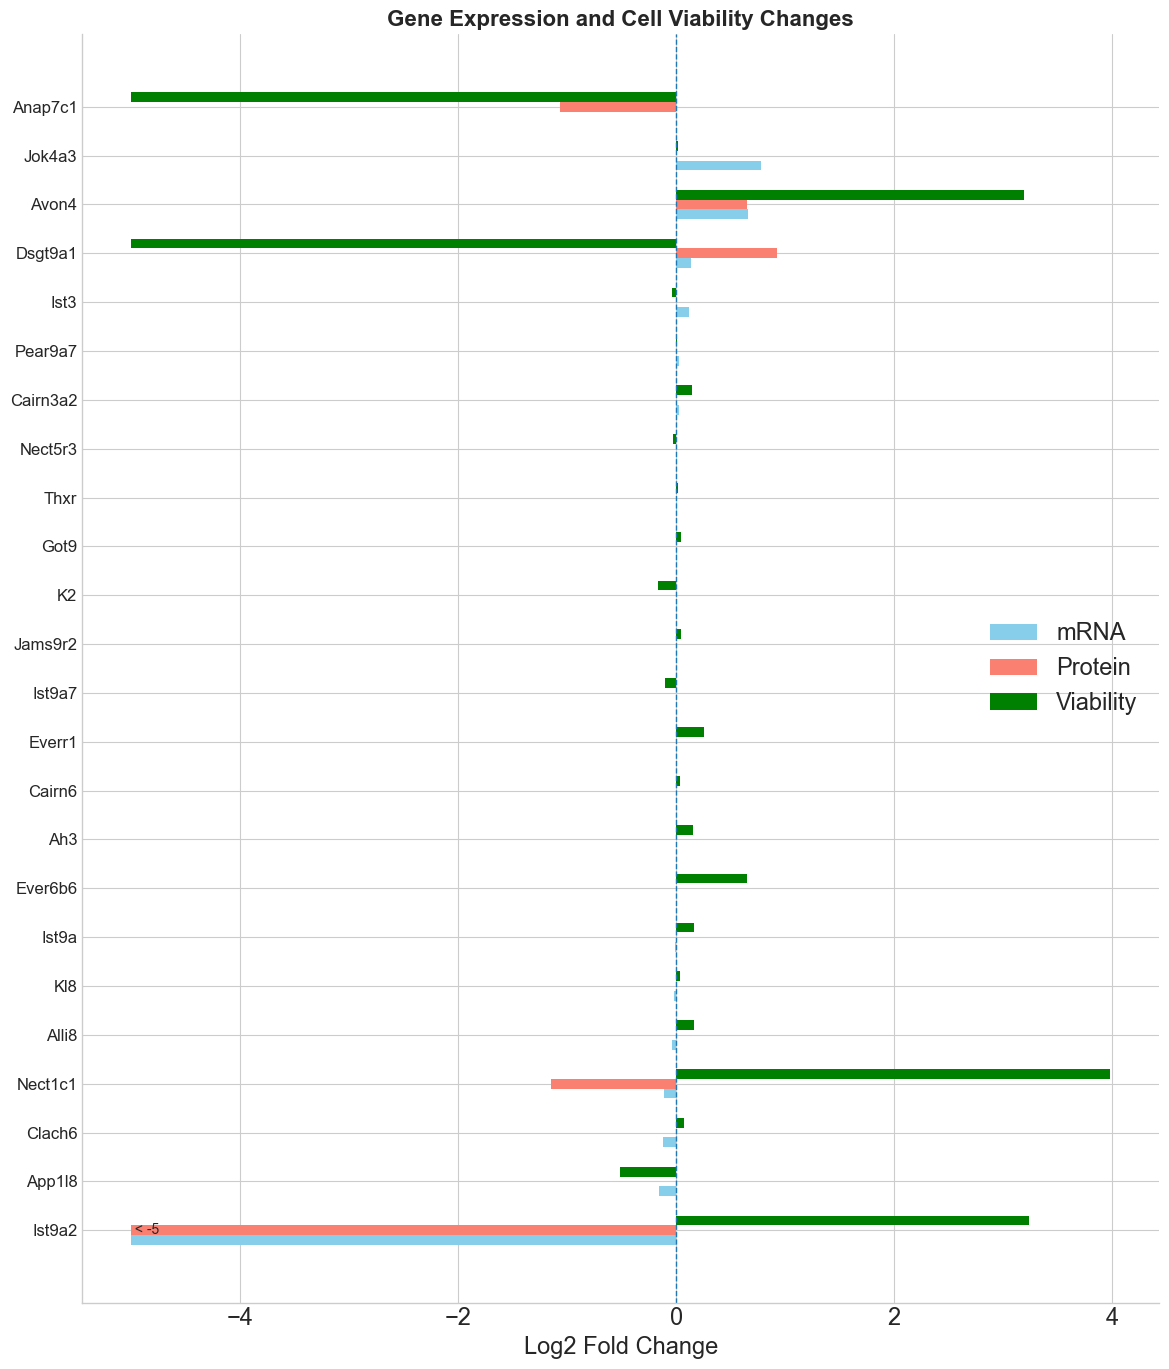

In [19]:
plt.style.use("seaborn-v0_8-whitegrid")

df_sorted = df.sort_values(by="mRNA_Log2FC")

genes = df_sorted["Gene"]
mRNA = df_sorted["mRNA_Log2FC"]
protein = df_sorted["protein_Log2FC"]
viability = df_sorted["CellViability_Log2FC"]

y = np.arange(len(genes))
h = 0.20

clip_min, clip_max = -5, 5
mRNA_c = np.clip(mRNA, clip_min, clip_max)
protein_c = np.clip(protein, clip_min, clip_max)
viability_c = np.clip(viability, clip_min, clip_max)

fig, ax = plt.subplots(figsize=(12, 14))

ax.barh(y - h, mRNA_c, height=h, label="mRNA", color="skyblue")
ax.barh(y,     protein_c, height=h, label="Protein", color="salmon")
ax.barh(y + h, viability_c, height=h, label="Viability", color="green")

ax.set_yticks(y)
ax.set_yticklabels(genes, fontsize=12)

ax.set_xlabel("Log2 Fold Change")
ax.set_title("Gene Expression and Cell Viability Changes", fontsize=16, weight='bold')

ax.axvline(0, linestyle="--", linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
ax.legend()

for i, v in enumerate(protein):
    if v < clip_min:
        ax.text(clip_min, i, " < -5", va='center', fontsize=10)

plt.tight_layout()

In [20]:
df["Score"] = (
    abs(df["protein_Log2FC"])+      
    abs(df["mRNA_Log2FC"]) +
    abs(df["CellViability_Log2FC"]))

if "WildType" in df.columns and "Mutant" in df.columns:
    df["Mutation_Effect"] = abs(df["Mutant"] - df["WildType"])
    df["Score"] += df["Mutation_Effect"] 

df_filtered = df[(df["mRNA_Log2FC"] * df["protein_Log2FC"]) > 0]

top5 = df_filtered.sort_values("Score", ascending=False).head(5)

print(top5[["Gene", "mutation.type", "mRNA_Log2FC", "protein_Log2FC", "CellViability_Log2FC", "Score"]])

       Gene mutation.type  mRNA_Log2FC  protein_Log2FC  CellViability_Log2FC  \
17  Dsgt9a1     insertion     0.136741        0.927237                  -inf   
20   Ist9a2      deletion   -27.735259      -16.937899              3.240110   
9   Nect1c1      deletion    -0.115789       -1.151863              3.979476   
21    Avon4     insertion     0.655611        0.648166              3.189406   
14   Jok4a3  substitution     0.777423        0.000601              0.014119   

        Score  
17        inf  
20  47.913268  
9    5.247128  
21   4.493183  
14   0.792144  
